In [1]:
import torch
torch.backends.mha.set_fastpath_enabled(False)

from torch.nn.attention import sdpa_kernel, SDPBackend

检查一下torch版本和gpu

In [2]:
import sys
import torch

print(sys.executable)
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

d:\anaconda\python.exe
2.11.0+cu128
12.8
True
NVIDIA GeForce RTX 4060 Laptop GPU


下面这句它会把 D:\anaconda\python.exe 这个 Python 环境里的 PyTorch 换成 CUDA 12.8 版本

In [4]:
import sys
!"{sys.executable}" -m pip install --upgrade --force-reinstall torch --index-url https://download.pytorch.org/whl/cu128

^C


In [3]:
import sys
sys.path.insert(0, r"D:\MEGNET_GITHUB\matgl\src")

In [5]:
import torch
from pymatgen.core import Lattice, Structure
from matgl.models._m3gnet import M3GNet
from matgl.ext.pymatgen import Structure2Graph
from matgl.apps.pes import Potential

structure = Structure(
    Lattice.cubic(5.43),
    ["Si", "Si"],
    [[0, 0, 0], [0.25, 0.25, 0.25]],
)

model = M3GNet(
    element_types=("Si",),
    is_intensive=True,
    readout_type="transformer",
    transformer_nhead=4,
    transformer_num_layers=1,
    transformer_dim_ff=128,
    transformer_dropout=0.0,
)

pot = Potential(  #potential 是定义的一个类可以把model输出的能量变成力和应力
    model=model,
    calc_forces=True,
    calc_stresses=False,
)

converter = Structure2Graph(
    element_types=("Si",),
    cutoff=model.cutoff,
)

g, lat, state_attr = converter.get_graph(structure)

model.eval()
pot.eval()

energy, forces, stresses, hessian = pot(
    g=g,
    lat=lat,
    state_attr=torch.tensor(state_attr, dtype=torch.float32),
)

print("energy:", energy)
print("forces:", forces)
print("forces shape:", forces.shape)
print("forces finite:", torch.isfinite(forces).all())
print("final layer:", type(model.final_layer).__name__)

energy: tensor(0.0805, grad_fn=<AddBackward0>)
forces: tensor([[-0.0002, -0.0002, -0.0002],
        [ 0.0002,  0.0002,  0.0002]])
forces shape: torch.Size([2, 3])
forces finite: tensor(True)
final layer: TransformerReadOut


结果说明：TransformerReadOut + Potential 前向 + force 计算 可以跑

In [6]:
with torch.no_grad():
    out = model.predict_structure(structure)

print("model output:", out)
print(model.feature_dict.keys())
print("readout_type:", model.readout_type)
print("final layer:", type(model.final_layer).__name__)
print("readout value:", model.feature_dict["readout"])
print("final value:", model.feature_dict["final"])

model output: tensor(0.0805)
dict_keys(['bond_expansion', 'three_body_basis', 'embedding', 'gc_1', 'gc_2', 'gc_3', 'readout', 'final'])
readout_type: transformer
final layer: TransformerReadOut
readout value: tensor([[0.0805]])
final value: tensor([[0.0805]])


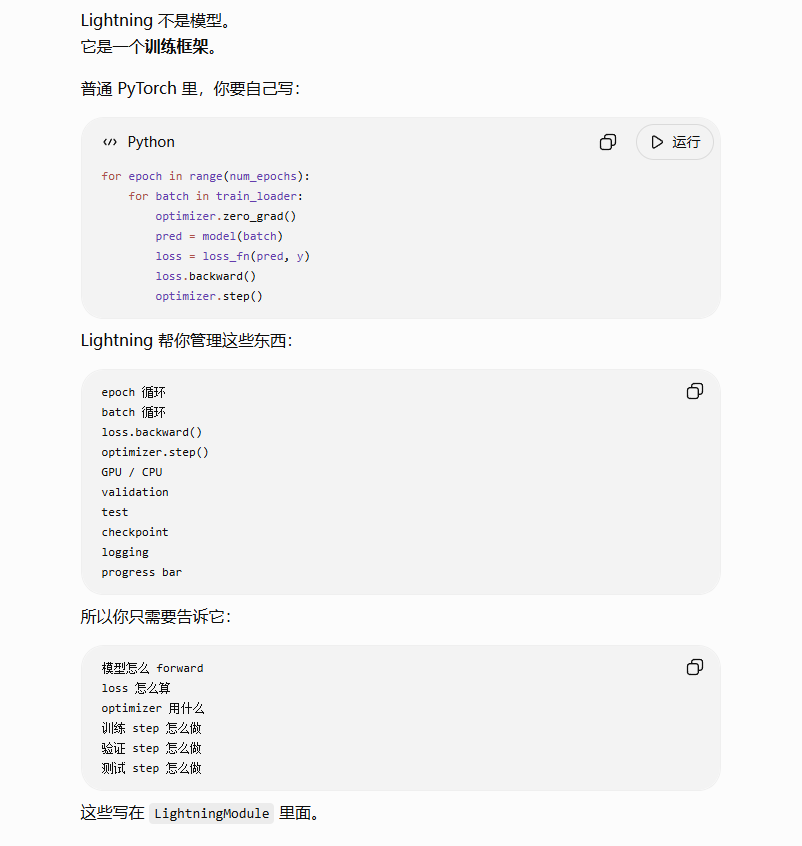

开始训练流程：
MGLDataset      把 structures + labels 变成图数据集

MGLDataLoader   每次取一批 graph

PotentialLightningModule  把 model 包装成 Lightning 可训练对象

Trainer         真正跑训练循环


In [4]:
import numpy as np
import lightning as L

from functools import partial
from lightning.pytorch.loggers import CSVLogger

from matgl.graph.data import MGLDataset, MGLDataLoader, collate_fn_pes, split_dataset
from matgl.utils.training import PotentialLightningModule

W0715 21:13:10.896000 21116 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [5]:
structures = []
energies = []
forces = []
#这里写了6个si晶体结构的toy数据集
for i, a in enumerate([5.35, 5.40, 5.43, 5.46, 5.50, 5.55]):
    s = Structure(
        Lattice.cubic(a),
        ["Si", "Si"],
        [[0, 0, 0], [0.25, 0.25, 0.25]],
    )
    structures.append(s)

    # 只是为了测试训练流程的假标签，不代表真实 DFT
    energies.append(-10.0 + 0.1 * (a - 5.43) ** 2)

    # 先用零力测试流程，真实训练要换成 DFT forces
    forces.append(np.zeros((len(s), 3)).tolist())

labels = {
    "energies": energies,
    "forces": forces,
}

print(len(structures), energies[0], np.array(forces[0]).shape)

NameError: name 'Structure' is not defined

数据组织流程没问题
你现在成功构造了：
structures: 6 个 pymatgen Structure
energies: 6 个标量能量标签
forces: 每个结构一个 [num_atoms, 3] 的力标签

这一步只是测试训练管线，不是科学训练。真实 PES 训练时，energies / forces 必须来自 DFT 数据。

In [9]:
converter = Structure2Graph(
    element_types=("Si",),
    cutoff=5.0,
)

dataset = MGLDataset(
    structures=structures,
    converter=converter,
    labels=labels,
    root="tmp_m3gnet_transformer_toy",
    save_cache=False,
)

train_data, val_data, test_data = split_dataset(
    dataset,
    frac_list=[0.67, 0.17, 0.16],
    shuffle=True,
    random_state=42,
)

my_collate_fn = partial(collate_fn_pes, include_stress=False)

train_loader, val_loader, test_loader = MGLDataLoader(
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    collate_fn=my_collate_fn,
    batch_size=2,
    num_workers=0,
)

print(len(train_data), len(val_data), len(test_data))

Processing...
100%|██████████| 6/6 [00:00<00:00, 2736.90it/s]

4 1 1



Done!


toy 数据已经成功转成 MatGL/PyG 能吃的数据集，并且 dataloader 也建好了。
具体过程是：


Structure2Graph OK


MGLDataset OK


train/val/test split OK


MGLDataLoader OK

重新建一个训练用 Transformer-M3GNet

In [10]:
train_model = M3GNet(
    element_types=("Si",),
    is_intensive=True,
    readout_type="transformer",
    transformer_nhead=4,
    transformer_num_layers=1,
    transformer_dim_ff=128,
    transformer_dropout=0.0,
)

print("readout_type:", train_model.readout_type)
print("final layer:", type(train_model.final_layer).__name__)

readout_type: transformer
final layer: TransformerReadOut


包成 LightningModule

In [11]:
lit_module = PotentialLightningModule(
    model=train_model,
    energy_weight=1.0,
    force_weight=1.0,#损失函数里面的权重系数
    stress_weight=0.0,
    lr=1e-3,
)

把train_model = M3GNet(...)包装秤一个lightning能训练的对象

上述：train_model 负责 graph -> energy
PotentialLightningModule 负责 energy/force loss 和训练

然后跑一个epoch

In [12]:
logger = CSVLogger("logs", name="m3gnet_transformer_toy")

trainer = L.Trainer(
    max_epochs=1,
    accelerator="gpu",
    logger=logger,
    inference_mode=False,
    log_every_n_steps=1,
    num_sanity_val_steps=0,
)

with sdpa_kernel(SDPBackend.MATH): #这么写是为了能二阶
    trainer.fit(
        model=lit_module,
        train_dataloaders=train_loader,
        val_dataloaders=val_loader,
    )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 1 │ rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 2 │ model │ Potential         │  290 K │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 290 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 290 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 169                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

d:\anaconda\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\anaconda\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
d:\anaconda\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


`Trainer.fit` stopped: `max_epochs=1` reached.


现在的流程：

trainer.fit


-> PotentialLightningModule.training_step


-> Potential(model)


-> M3GNet + TransformerReadOut


-> energy


-> forces = -dE/dR


-> force_loss


-> backward



In [13]:
trainer.test(
    model=lit_module,
    dataloaders=test_loader,
    ckpt_path=None,
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_Charge_MAE      │            0.0            │
│     test_Charge_RMSE      │            0.0            │
│      test_Energy_MAE      │     4.185337066650391     │
│     test_Energy_RMSE      │     4.185337066650391     │
│      test_Force_MAE       │   2.496474189683795e-05   │
│      test_Force_RMSE      │   2.496474189683795e-05   │
│      test_Magmom_MAE      │            0.0            │
│     test_Magmom_RMSE      │            0.0            │
│      test_Stress_MAE      │            0.0            │
│     test_Stress_RMSE      │            0.0            │
│      test_Total_Loss      │    17.517045974731445     │
└───────────────────────────┴───────────────────────────┘

d:\anaconda\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


[{'test_Total_Loss': 17.517045974731445,
  'test_Energy_MAE': 4.185337066650391,
  'test_Force_MAE': 2.496474189683795e-05,
  'test_Stress_MAE': 0.0,
  'test_Magmom_MAE': 0.0,
  'test_Charge_MAE': 0.0,
  'test_Energy_RMSE': 4.185337066650391,
  'test_Force_RMSE': 2.496474189683795e-05,
  'test_Stress_RMSE': 0.0,
  'test_Magmom_RMSE': 0.0,
  'test_Charge_RMSE': 0.0}]

已确认修改后的 M3GNet + TransformerReadOut 可以接入 MatGL 官方 PotentialLightningModule，并完成 energy/force PES training pipeline 的 train/validation/test。

接下来拿真实数据小子集开始试试，：


真实 MatPES 数据


↓
取 100~1000 条小子集


↓
训练 Transformer-readout M3GNet 1 个 epoch


↓
确认真实 energy/force/stress loss 能跑


In [13]:
%pip install ijson -q

Note: you may need to restart the kernel to use updated packages.


下一步会下载真实 MatPES-PBE 数据。第一次会比较久，文件也大。

In [6]:
import json
import ijson
from pathlib import Path
from huggingface_hub import hf_hub_download

# 先用 PBE-2025.2，和 MatGL 新版 M3GNet-PES-MatPES-PBE-2025.2 更接近
raw_path = hf_hub_download(
    repo_id="materialyze/matpes",
    filename="MatPES-PBE-2025.2.json",
    repo_type="dataset",
)

raw_path

'C:\\Users\\ASUS\\.cache\\huggingface\\hub\\datasets--materialyze--matpes\\snapshots\\47d2cc020cf913b5a48a3480136a128dddc0a92c\\MatPES-PBE-2025.2.json'

切一个小子集

In [7]:
import json
import ijson
from pathlib import Path

N = 200
subset_path = Path(f"MatPES-PBE-2025.2-subset-{N}.json")
tmp_path = subset_path.with_suffix(".tmp")

subset_path.unlink(missing_ok=True)
tmp_path.unlink(missing_ok=True)

count = 0
with open(raw_path, "rb") as f, open(tmp_path, "w", encoding="utf-8") as out:
    out.write("[\n")
    for i, item in enumerate(ijson.items(f, "item", use_float=True)):
        if i >= N:
            break
        if i > 0:
            out.write(",\n")
        json.dump(item, out)
        count += 1
    out.write("\n]\n")

tmp_path.replace(subset_path)

print("saved:", subset_path)
print("count:", count)
print("size MB:", subset_path.stat().st_size / 1024 / 1024)

saved: MatPES-PBE-2025.2-subset-200.json
count: 200
size MB: 0.44304370880126953


In [8]:
with open(subset_path, encoding="utf-8") as f:
    subset = json.load(f)

print(len(subset))
print(subset[0].keys())

200
dict_keys(['builder_meta', 'nsites', 'elements', 'nelements', 'composition', 'composition_reduced', 'formula_pretty', 'formula_anonymous', 'chemsys', 'volume', 'density', 'density_atomic', 'symmetry', 'structure', 'energy', 'forces', 'stress', 'matpes_id', 'bandgap', 'functional', 'formation_energy_per_atom', 'cohesive_energy_per_atom', 'abs_forces', 'bader_charges', 'bader_magmoms', 'provenance'])


接下来：

读 200 条 MatPES json

-> 解析 structure / energy / forces / stress

-> Structure2Graph 建图

-> 生成 MGLDataset

MGLDatasetLoader.from_json(...)是MATGL项目自己封装好的方法

打开 MatPES json

↓
读取 structure / energy / forces / stress

↓
把 structure 转成 pymatgen Structure

↓
用 Structure2Graph 建图

↓
整理 labels

↓
构造成 MGLDataset


In [9]:
from matgl.config import DEFAULT_ELEMENTS
from matgl.utils.training import MGLDatasetLoader

real_dataset = MGLDatasetLoader.from_json(
    subset_path,
    cutoff=5.0,
    element_types=DEFAULT_ELEMENTS,
    save_cache=False,
    root="tmp_matpes_pbe_subset_200",
    stress_unit="kbar",
)

print("dataset size:", len(real_dataset))
print("labels:", real_dataset.labels.keys())

Processing...
100%|██████████| 200/200 [00:00<00:00, 3140.67it/s]

dataset size: 200
labels: dict_keys(['energies', 'forces', 'stresses'])



Done!


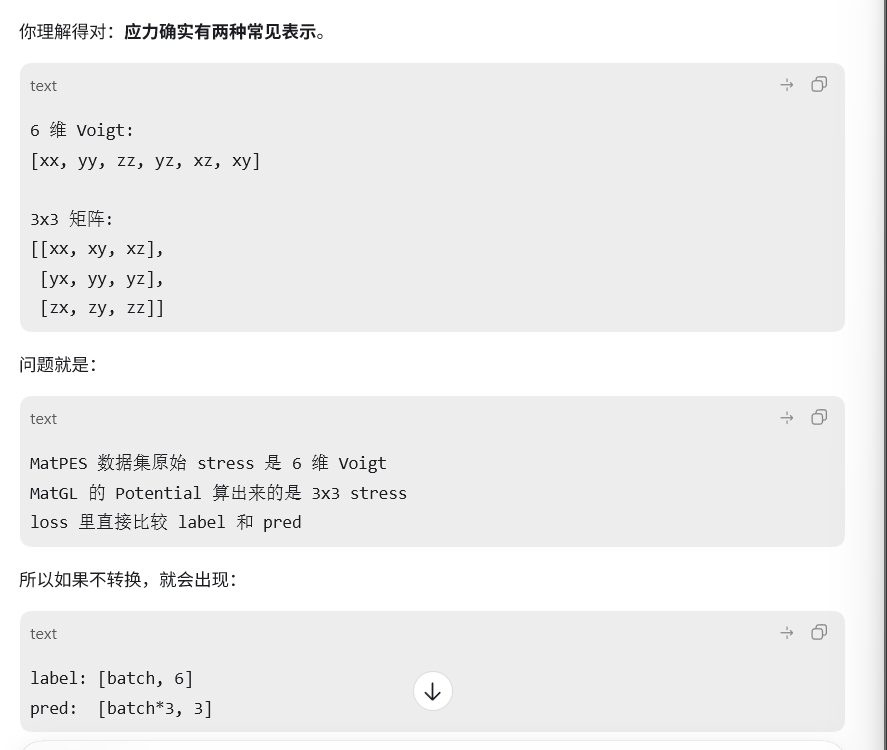

In [10]:
import numpy as np
from ase.stress import voigt_6_to_full_3x3_stress

fixed_stresses = []

for s in real_dataset.labels["stresses"]:
    s = np.asarray(s, dtype=float)

    if s.shape == (6,):
        s = voigt_6_to_full_3x3_stress(s)

    fixed_stresses.append(s.tolist())

real_dataset.labels["stresses"] = fixed_stresses

print(np.asarray(real_dataset.labels["stresses"][0]).shape)
print(real_dataset.labels["stresses"][0])

(3, 3)
[[0.571186022, -0.622290851, -2.3671935200000003], [-0.622290851, 0.9345902389999999, -2.284178803], [-2.3671935200000003, -2.284178803, -1.364346365]]


需要转换应力格式

然后切train/val/test，并创建dataloader

In [11]:
from functools import partial
from matgl.graph.data import MGLDataLoader, collate_fn_pes, split_dataset

real_train_data, real_val_data, real_test_data = split_dataset(
    real_dataset,
    frac_list=[0.8, 0.1, 0.1],
    shuffle=True,
    random_state=42,
)

real_collate_fn = partial(collate_fn_pes, include_stress=True)

real_train_loader, real_val_loader, real_test_loader = MGLDataLoader(
    train_data=real_train_data,
    val_data=real_val_data,
    test_data=real_test_data,
    collate_fn=real_collate_fn,
    batch_size=2,
    num_workers=0,
)

print(len(real_train_data), len(real_val_data), len(real_test_data))

160 20 20


下一步创建一个真实数据训练用的transformer-m3gnet模型

In [12]:
from matgl.models import M3GNet
from matgl.config import DEFAULT_ELEMENTS

real_model = M3GNet(
    element_types=DEFAULT_ELEMENTS,
    is_intensive=True,
    readout_type="transformer",
    transformer_nhead=4,
    transformer_num_layers=1,
    transformer_dim_ff=128,
    transformer_dropout=0.0,
)

print("readout_type:", real_model.readout_type)
print("final layer:", type(real_model.final_layer).__name__)
print("num params:", sum(p.numel() for p in real_model.parameters()))

readout_type: transformer
final layer: TransformerReadOut
num params: 296604


把 real_model 包成 PotentialLightningModule，让它可以训练 energy / force / stress。

In [13]:
from matgl.utils.training import PotentialLightningModule

real_lit_module = PotentialLightningModule(
    model=real_model,
    energy_weight=1.0,
    force_weight=1.0,
    stress_weight=0.1,
    loss="huber_loss",
    lr=1e-3,
)

print("wrapped model:", type(real_lit_module.model).__name__)
print("energy_weight:", real_lit_module.energy_weight)
print("force_weight:", real_lit_module.force_weight)
print("stress_weight:", real_lit_module.stress_weight)

wrapped model: Potential
energy_weight: 1.0
force_weight: 1.0
stress_weight: 0.1


In [16]:
from lightning.pytorch.loggers import CSVLogger

real_logger = CSVLogger("logs", name="m3gnet_transformer_matpes_200")

real_trainer = L.Trainer(
    max_epochs=1,
    accelerator="gpu",
    devices=1,
    logger=real_logger,
    inference_mode=False,
    log_every_n_steps=1,
    num_sanity_val_steps=0,
)

with sdpa_kernel(SDPBackend.MATH):
    real_trainer.fit(
        model=real_lit_module,
        train_dataloaders=real_train_loader,
        val_dataloaders=real_val_loader,
    )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 1 │ rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 2 │ model │ Potential         │  296 K │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 296 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 296 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 169                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=1` reached.


In [17]:
with sdpa_kernel(SDPBackend.MATH):
    real_test_result = real_trainer.test(
        model=real_lit_module,
        dataloaders=real_test_loader,
        ckpt_path=None,
    )

real_test_result

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_Charge_MAE      │            0.0            │
│     test_Charge_RMSE      │            0.0            │
│      test_Energy_MAE      │    0.7489867210388184     │
│     test_Energy_RMSE      │    0.7609186172485352     │
│      test_Force_MAE       │    0.2519228458404541     │
│      test_Force_RMSE      │    0.3259074091911316     │
│      test_Magmom_MAE      │            0.0            │
│     test_Magmom_RMSE      │            0.0            │
│      test_Stress_MAE      │     4.869455814361572     │
│     test_Stress_RMSE      │     6.296727180480957     │
│      test_Total_Loss      │    0.8155919909477234     │
└───────────────────────────┴───────────────────────────┘

[{'test_Total_Loss': 0.8155919909477234,
  'test_Energy_MAE': 0.7489867210388184,
  'test_Force_MAE': 0.2519228458404541,
  'test_Stress_MAE': 4.869455814361572,
  'test_Magmom_MAE': 0.0,
  'test_Charge_MAE': 0.0,
  'test_Energy_RMSE': 0.7609186172485352,
  'test_Force_RMSE': 0.3259074091911316,
  'test_Stress_RMSE': 6.296727180480957,
  'test_Magmom_RMSE': 0.0,
  'test_Charge_RMSE': 0.0}]

在更大的样本上试试，以及更多的轮次

In [18]:
N_BIG = 1000
EPOCHS_BIG = 5
BATCH_SIZE_BIG = 2

In [19]:
import json
import ijson
from pathlib import Path

N_BIG = 1000
subset_big_path = Path(f"MatPES-PBE-2025.2-subset-{N_BIG}.json")
tmp_path = subset_big_path.with_suffix(".tmp")

if not subset_big_path.exists():
    count = 0
    with open(raw_path, "rb") as f, open(tmp_path, "w", encoding="utf-8") as out:
        out.write("[\n")
        for i, item in enumerate(ijson.items(f, "item", use_float=True)):
            if i >= N_BIG:
                break
            if i > 0:
                out.write(",\n")
            json.dump(item, out)
            count += 1
        out.write("\n]\n")
    tmp_path.replace(subset_big_path)

print(subset_big_path)
print("size MB:", subset_big_path.stat().st_size / 1024 / 1024)

MatPES-PBE-2025.2-subset-1000.json
size MB: 2.212296485900879


构造 dataset，并转换 stress：(因为重新切了一遍)

In [20]:
import numpy as np
from ase.stress import voigt_6_to_full_3x3_stress
from matgl.config import DEFAULT_ELEMENTS
from matgl.utils.training import MGLDatasetLoader

big_dataset = MGLDatasetLoader.from_json(
    subset_big_path,
    cutoff=5.0,
    element_types=DEFAULT_ELEMENTS,
    save_cache=False,
    root=f"tmp_matpes_pbe_subset_{N_BIG}",
    stress_unit="kbar",
)

fixed_stresses = []
for s in big_dataset.labels["stresses"]:
    s = np.asarray(s, dtype=float)
    if s.shape == (6,):
        s = voigt_6_to_full_3x3_stress(s)
    fixed_stresses.append(s.tolist())

big_dataset.labels["stresses"] = fixed_stresses

print(len(big_dataset))
print(np.asarray(big_dataset.labels["stresses"][0]).shape)

Processing...
100%|██████████| 1000/1000 [00:00<00:00, 3134.88it/s]

1000
(3, 3)



Done!


split 和 dataloader：

In [21]:
from functools import partial
from matgl.graph.data import MGLDataLoader, collate_fn_pes, split_dataset

big_train_data, big_val_data, big_test_data = split_dataset(
    big_dataset,
    frac_list=[0.8, 0.1, 0.1],
    shuffle=True,
    random_state=42,
)

big_collate_fn = partial(collate_fn_pes, include_stress=True)

big_train_loader, big_val_loader, big_test_loader = MGLDataLoader(
    train_data=big_train_data,
    val_data=big_val_data,
    test_data=big_test_data,
    collate_fn=big_collate_fn,
    batch_size=BATCH_SIZE_BIG,
    num_workers=0,
)

print(len(big_train_data), len(big_val_data), len(big_test_data))

800 100 100


训练 Transformer-M3GNet：

In [22]:
import lightning as L
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint
from matgl.models import M3GNet
from matgl.utils.training import PotentialLightningModule, xavier_init

L.seed_everything(42, workers=True)

big_tf_model = M3GNet(
    element_types=DEFAULT_ELEMENTS,
    is_intensive=True,
    readout_type="transformer",
    transformer_nhead=4,
    transformer_num_layers=1,
    transformer_dim_ff=128,
    transformer_dropout=0.0,
)

xavier_init(big_tf_model)

big_tf_lit = PotentialLightningModule(
    model=big_tf_model,
    energy_weight=1.0,
    force_weight=1.0,
    stress_weight=0.1,
    loss="huber_loss",
    lr=1e-3,
)

big_tf_logger = CSVLogger("logs", name=f"m3gnet_transformer_matpes_{N_BIG}_ep{EPOCHS_BIG}")

big_tf_ckpt = ModelCheckpoint(
    monitor="val_Total_Loss",
    mode="min",
    save_top_k=1,
    filename="{epoch:03d}-{step}-best",
)

big_tf_trainer = L.Trainer(
    max_epochs=EPOCHS_BIG,
    accelerator="gpu",
    devices=1,
    logger=big_tf_logger,
    callbacks=[big_tf_ckpt],
    inference_mode=False,
    log_every_n_steps=10,
    num_sanity_val_steps=0,
    gradient_clip_val=2.0,
)

with sdpa_kernel(SDPBackend.MATH):
    big_tf_trainer.fit(
        model=big_tf_lit,
        train_dataloaders=big_train_loader,
        val_dataloaders=big_val_loader,
    )

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 1 │ rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 2 │ model │ Potential         │  296 K │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 296 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 296 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 169                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=5` reached.


In [23]:
total_params = sum(p.numel() for p in big_tf_model.parameters())
trainable_params = sum(p.numel() for p in big_tf_model.parameters() if p.requires_grad)

print("total params:", total_params)
print("trainable params:", trainable_params)

total params: 296604
trainable params: 296604


In [24]:
with sdpa_kernel(SDPBackend.MATH):
    big_tf_test = big_tf_trainer.test(
        model=big_tf_lit,
        dataloaders=big_test_loader,
        ckpt_path="best",
    )

big_tf_test

Restoring states from the checkpoint path at logs\m3gnet_transformer_matpes_1000_ep5\version_2\checkpoints\epoch=004-step=2000-best.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at logs\m3gnet_transformer_matpes_1000_ep5\version_2\checkpoints\epoch=004-step=2000-best.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_Charge_MAE      │            0.0            │
│     test_Charge_RMSE      │            0.0            │
│      test_Energy_MAE      │    0.30012521147727966    │
│     test_Energy_RMSE      │    0.3421885371208191     │
│      test_Force_MAE       │    0.23613816499710083    │
│      test_Force_RMSE      │    0.30455857515335083    │
│      test_Magmom_MAE      │            0.0            │
│     test_Magmom_RMSE      │            0.0            │
│      test_Stress_MAE      │     3.635301113128662     │
│     test_Stress_RMSE      │     5.237358570098877     │
│      test_Total_Loss      │    0.4737716317176819     │
└───────────────────────────┴───────────────────────────┘

[{'test_Total_Loss': 0.4737716317176819,
  'test_Energy_MAE': 0.30012521147727966,
  'test_Force_MAE': 0.23613816499710083,
  'test_Stress_MAE': 3.635301113128662,
  'test_Magmom_MAE': 0.0,
  'test_Charge_MAE': 0.0,
  'test_Energy_RMSE': 0.3421885371208191,
  'test_Force_RMSE': 0.30455857515335083,
  'test_Stress_RMSE': 5.237358570098877,
  'test_Magmom_RMSE': 0.0,
  'test_Charge_RMSE': 0.0}]

接下来做一个非transfomer的M3GNET

In [25]:
from matgl.models import M3GNet
from matgl.utils.training import PotentialLightningModule, xavier_init
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint

L.seed_everything(42, workers=True)

big_base_model = M3GNet(
    element_types=DEFAULT_ELEMENTS,
    is_intensive=False,
)

xavier_init(big_base_model)

print("is_intensive:", big_base_model.is_intensive)
print("final layer:", type(big_base_model.final_layer).__name__)
print("total params:", sum(p.numel() for p in big_base_model.parameters()))
print("trainable params:", sum(p.numel() for p in big_base_model.parameters() if p.requires_grad))

Seed set to 42


is_intensive: False
final layer: WeightedReadOut
total params: 288157
trainable params: 288157


In [26]:
big_base_lit = PotentialLightningModule(
    model=big_base_model,
    energy_weight=1.0,
    force_weight=1.0,
    stress_weight=0.1,
    loss="huber_loss",
    lr=1e-3,
)

In [27]:
big_base_logger = CSVLogger("logs", name=f"m3gnet_baseline_matpes_{N_BIG}_ep{EPOCHS_BIG}")

big_base_ckpt = ModelCheckpoint(
    monitor="val_Total_Loss",
    mode="min",
    save_top_k=1,
    filename="{epoch:03d}-{step}-best",
)

big_base_trainer = L.Trainer(
    max_epochs=EPOCHS_BIG,
    accelerator="gpu",
    devices=1,
    logger=big_base_logger,
    callbacks=[big_base_ckpt],
    inference_mode=False,
    log_every_n_steps=10,
    num_sanity_val_steps=0,
    gradient_clip_val=2.0,
)

big_base_trainer.fit(
    model=big_base_lit,
    train_dataloaders=big_train_loader,
    val_dataloaders=big_val_loader,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 1 │ rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 2 │ model │ Potential         │  288 K │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 288 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 288 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 174                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=5` reached.


In [ ]:
big_base_test = big_base_trainer.test(
    model=big_base_lit,
    dataloaders=big_test_loader,
    ckpt_path="best",
)

big_base_test

Restoring states from the checkpoint path at logs\m3gnet_baseline_matpes_1000_ep5\version_1\checkpoints\epoch=004-step=2000-best.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at logs\m3gnet_baseline_matpes_1000_ep5\version_1\checkpoints\epoch=004-step=2000-best.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_Charge_MAE      │            0.0            │
│     test_Charge_RMSE      │            0.0            │
│      test_Energy_MAE      │     0.332952082157135     │
│     test_Energy_RMSE      │    0.3853151798248291     │
│      test_Force_MAE       │    0.24797220528125763    │
│      test_Force_RMSE      │    0.32056862115859985    │
│      test_Magmom_MAE      │            0.0            │
│     test_Magmom_RMSE      │            0.0            │
│      test_Stress_MAE      │     3.740638017654419     │
│     test_Stress_RMSE      │     5.400104522705078     │
│      test_Total_Loss      │    0.5187935829162598     │
└───────────────────────────┴───────────────────────────┘

[{'test_Total_Loss': 0.5187935829162598,
  'test_Energy_MAE': 0.332952082157135,
  'test_Force_MAE': 0.24797220528125763,
  'test_Stress_MAE': 3.740638017654419,
  'test_Magmom_MAE': 0.0,
  'test_Charge_MAE': 0.0,
  'test_Energy_RMSE': 0.3853151798248291,
  'test_Force_RMSE': 0.32056862115859985,
  'test_Stress_RMSE': 5.400104522705078,
  'test_Magmom_RMSE': 0.0,
  'test_Charge_RMSE': 0.0}]

在 MatPES-PBE-1000 / 5 epochs / batch=2 的初步实验中，
Transformer readout 相比 baseline 改善了 energy MAE，
force 有小幅改善，
stress 基本持平。

这是 reservoir sampling：

顺序扫描完整的 2.2 GB JSON；

不把完整数据集加载进内存；

最终只保留 5 万条；

每条原始记录被选中的概率相同；

seed=42 保证以后能够复现实验。

扫描完整文件需要一些时间，这是正常的。

In [24]:
import json
import random
import ijson

from pathlib import Path
from huggingface_hub import hf_hub_download

# 即使重启了 notebook，也能重新得到原始数据路径
raw_path = Path(
    hf_hub_download(
        repo_id="materialyze/matpes",
        filename="MatPES-PBE-2025.2.json",
        repo_type="dataset",
    )
)

N_SAMPLE = 50_000       # 确认正常后可改成 100_000
RANDOM_SEED = 42

random_subset_path = Path(
    f"MatPES-PBE-2025.2-random-{N_SAMPLE}-seed-{RANDOM_SEED}.json"
)
tmp_path = random_subset_path.with_suffix(".json.tmp")

rng = random.Random(RANDOM_SEED)
reservoir = []
seen = 0

if not random_subset_path.exists():
    with raw_path.open("rb") as f:
        for seen, item in enumerate(
            ijson.items(f, "item", use_float=True),
            start=1,
        ):
            if seen <= N_SAMPLE:
                # 保存成字符串比保存 Python dict 更省内存
                reservoir.append(
                    json.dumps(
                        item,
                        ensure_ascii=False,
                        separators=(",", ":"),
                    )
                )
            else:
                # Reservoir sampling：所有记录被选中的概率相同
                j = rng.randrange(seen)
                if j < N_SAMPLE:
                    reservoir[j] = json.dumps(
                        item,
                        ensure_ascii=False,
                        separators=(",", ":"),
                    )

            if seen % 100_000 == 0:
                print(f"已经扫描 {seen:,} 条")

    if seen < N_SAMPLE:
        raise ValueError(
            f"完整数据只有 {seen} 条，少于要求的 {N_SAMPLE} 条"
        )

    # 打乱 reservoir 内部顺序
    rng.shuffle(reservoir)

    with tmp_path.open("w", encoding="utf-8") as out:
        out.write("[\n")
        out.write(",\n".join(reservoir))
        out.write("\n]\n")

    tmp_path.replace(random_subset_path)

print("随机子集：", random_subset_path.resolve())
print("文件大小：", random_subset_path.stat().st_size / 1024**2, "MB")

已经扫描 100,000 条
已经扫描 200,000 条
已经扫描 300,000 条
已经扫描 400,000 条
随机子集： D:\MEGNET_GITHUB\matgl\MatPES-PBE-2025.2-random-50000-seed-42.json
文件大小： 237.79107856750488 MB


In [25]:
from collections import Counter
import statistics

num_structures = 0
num_atoms = []
formulas = Counter()

with random_subset_path.open("rb") as f:
    for item in ijson.items(f, "item", use_float=True):
        num_structures += 1
        num_atoms.append(item["nsites"])
        formulas[item["formula_pretty"]] += 1

print("结构数量：", num_structures)
print("原子数最小值：", min(num_atoms))
print("原子数中位数：", statistics.median(num_atoms))
print("原子数最大值：", max(num_atoms))
print("不同化学式数量：", len(formulas))

结构数量： 50000
原子数最小值： 1
原子数中位数： 5.0
原子数最大值： 240
不同化学式数量： 22907


In [26]:
import numpy as np

from ase.stress import voigt_6_to_full_3x3_stress
from matgl.config import DEFAULT_ELEMENTS
from matgl.utils.training import MGLDatasetLoader

large_dataset = MGLDatasetLoader.from_json(
    random_subset_path,
    cutoff=5.0,
    element_types=DEFAULT_ELEMENTS,
    save_cache=True,
    root=f"tmp_matpes_random_{N_SAMPLE}_seed_{RANDOM_SEED}",
    stress_unit="kbar",
)

fixed_stresses = []

for stress in large_dataset.labels["stresses"]:
    stress = np.asarray(stress, dtype=float)

    if stress.shape == (6,):
        stress = voigt_6_to_full_3x3_stress(stress)

    fixed_stresses.append(stress.tolist())

large_dataset.labels["stresses"] = fixed_stresses

print("dataset size:", len(large_dataset))
print(
    "stress shape:",
    np.asarray(large_dataset.labels["stresses"][0]).shape,
)

Processing...
100%|██████████| 50000/50000 [00:20<00:00, 2436.31it/s]
Done!


dataset size: 50000
stress shape: (3, 3)


In [27]:
from functools import partial

from matgl.graph.data import (
    MGLDataLoader,
    collate_fn_pes,
    split_dataset,
)

large_train_data, large_val_data, large_test_data = split_dataset(
    large_dataset,
    frac_list=[0.8, 0.1, 0.1],
    shuffle=True,
    random_state=42,
)

large_collate_fn = partial(
    collate_fn_pes,
    include_stress=True,
)

large_train_loader, large_val_loader, large_test_loader = MGLDataLoader(
    train_data=large_train_data,
    val_data=large_val_data,
    test_data=large_test_data,
    collate_fn=large_collate_fn,
    batch_size=2,
    num_workers=0,
)

print(
    len(large_train_data),
    len(large_val_data),
    len(large_test_data),
)

40000 5000 5000


In [28]:
import lightning as L

from matgl.models._m3gnet import M3GNet
from matgl.utils.training import (
    PotentialLightningModule,
    xavier_init,
)

# 固定随机初始化，方便以后与 baseline 公平比较
L.seed_everything(42, workers=True)

large_tf_model = M3GNet(
    element_types=DEFAULT_ELEMENTS,

    # 当前复现的是 DiepFormer 风格：
    # TransformerEncoder -> max pooling -> Linear
    is_intensive=True,
    readout_type="transformer",

    transformer_nhead=4,
    transformer_num_layers=1,
    transformer_dim_ff=128,
    transformer_dropout=0.0,
)

# 从头初始化模型参数
xavier_init(large_tf_model)

large_tf_lit = PotentialLightningModule(
    model=large_tf_model,

    # 总损失 = energy + force + 0.1 * stress
    energy_weight=1.0,
    force_weight=1.0,
    stress_weight=0.1,

    loss="huber_loss",
    lr=1e-3,
)

print("readout type:", large_tf_model.readout_type)
print("is intensive:", large_tf_model.is_intensive)
print("final layer:", type(large_tf_model.final_layer).__name__)
print(
    "trainable params:",
    sum(
        p.numel()
        for p in large_tf_model.parameters()
        if p.requires_grad
    ),
)
print("train batches:", len(large_train_loader))
print("val batches:", len(large_val_loader))
print("test batches:", len(large_test_loader))

Seed set to 42


readout type: transformer
is intensive: True
final layer: TransformerReadOut
trainable params: 296604
train batches: 20000
val batches: 2500
test batches: 2500


接下来直接跑 5 个训练 batch + 2 个验证 batch，同时记录时间和峰值显存。这 5 个 batch 会真实执行：
graph batch

→ M3GNet

→ TransformerEncoder

→ max pooling

→ energy

→ 对坐标求导得到 force

→ 对晶格求导得到 stress

→ energy/force/stress loss

→ 二阶梯度 backward

→ 更新模型参数

In [29]:
import time
import torch
import lightning as L

from torch.nn.attention import sdpa_kernel, SDPBackend

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

smoke_trainer = L.Trainer(
    max_epochs=1,
    accelerator="gpu",
    devices=1,

    # 只跑少量 batch，验证完整训练链路
    limit_train_batches=5,
    limit_val_batches=2,

    logger=False,
    enable_checkpointing=False,
    inference_mode=False,
    num_sanity_val_steps=0,
    log_every_n_steps=1,
    gradient_clip_val=2.0,
)

start_time = time.perf_counter()

with sdpa_kernel(SDPBackend.MATH):
    smoke_trainer.fit(
        model=large_tf_lit,
        train_dataloaders=large_train_loader,
        val_dataloaders=large_val_loader,
    )

elapsed = time.perf_counter() - start_time
peak_memory_gb = torch.cuda.max_memory_allocated() / 1024**3

print(f"smoke test time: {elapsed:.2f} s")
print(f"peak GPU memory: {peak_memory_gb:.2f} GB")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 1 │ rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 2 │ model │ Potential         │  296 K │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 296 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 296 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 169                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=1` reached.


smoke test time: 1.38 s
peak GPU memory: 0.22 GB


In [30]:
import time
import torch
import lightning as L

from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from torch.nn.attention import sdpa_kernel, SDPBackend

# 单独保存这次 5 万条实验
large_logger = CSVLogger(
    "logs",
    name=f"m3gnet_transformer_random_{N_SAMPLE}_epoch1",
)

large_checkpoint = ModelCheckpoint(
    monitor="val_Total_Loss",
    mode="min",
    save_top_k=1,
    filename="{epoch:03d}-{step}-best",
)

large_trainer = L.Trainer(
    max_epochs=1,
    accelerator="gpu",
    devices=1,

    logger=large_logger,
    callbacks=[large_checkpoint],

    inference_mode=False,
    num_sanity_val_steps=0,
    log_every_n_steps=100,
    gradient_clip_val=2.0,
)

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

start_time = time.perf_counter()

with sdpa_kernel(SDPBackend.MATH):
    large_trainer.fit(
        model=large_tf_lit,
        train_dataloaders=large_train_loader,
        val_dataloaders=large_val_loader,
    )

elapsed = time.perf_counter() - start_time
peak_memory_gb = torch.cuda.max_memory_allocated() / 1024**3

print(f"完整 1 epoch 耗时：{elapsed / 60:.2f} 分钟")
print(f"峰值 GPU 显存：{peak_memory_gb:.2f} GB")
print("最佳 checkpoint：", large_checkpoint.best_model_path)
print(
    "最佳 val_Total_Loss：",
    float(large_checkpoint.best_model_score),
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 1 │ rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 2 │ model │ Potential         │  296 K │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 296 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 296 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 169                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=1` reached.


完整 1 epoch 耗时：54.98 分钟
峰值 GPU 显存：1.70 GB
最佳 checkpoint： logs\m3gnet_transformer_random_50000_epoch1\version_0\checkpoints\epoch=000-step=20000-best.ckpt
最佳 val_Total_Loss： 2.268183708190918


In [32]:
import time
import torch

from torch.nn.attention import sdpa_kernel, SDPBackend

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

test_start = time.perf_counter()

with sdpa_kernel(SDPBackend.MATH):
    large_test_results = large_trainer.test(
        model=large_tf_lit,
        dataloaders=large_test_loader,

        # 明确加载刚才保存的最佳模型
        ckpt_path=large_checkpoint.best_model_path,
    )

test_elapsed = time.perf_counter() - test_start
test_peak_memory = torch.cuda.max_memory_allocated() / 1024**3

print("test results:")
print(large_test_results)
print(f"test time: {test_elapsed / 60:.2f} 分钟")
print(f"test peak GPU memory: {test_peak_memory:.2f} GB")

Restoring states from the checkpoint path at logs\m3gnet_transformer_random_50000_epoch1\version_0\checkpoints\epoch=000-step=20000-best.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at logs\m3gnet_transformer_random_50000_epoch1\version_0\checkpoints\epoch=000-step=20000-best.ckpt


Output()

d:\anaconda\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\anaconda\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_Charge_MAE      │            0.0            │
│     test_Charge_RMSE      │            0.0            │
│      test_Energy_MAE      │     2.237224578857422     │
│     test_Energy_RMSE      │     2.555295467376709     │
│      test_Force_MAE       │    0.4175315499305725     │
│      test_Force_RMSE      │    0.6264145374298096     │
│      test_Magmom_MAE      │            0.0            │
│     test_Magmom_RMSE      │            0.0            │
│      test_Stress_MAE      │    3.0636098384857178     │
│     test_Stress_RMSE      │     4.785796642303467     │
│      test_Total_Loss      │    2.2708165645599365     │
└───────────────────────────┴───────────────────────────┘

test results:
[{'test_Total_Loss': 2.2708165645599365, 'test_Energy_MAE': 2.237224578857422, 'test_Force_MAE': 0.4175315499305725, 'test_Stress_MAE': 3.0636098384857178, 'test_Magmom_MAE': 0.0, 'test_Charge_MAE': 0.0, 'test_Energy_RMSE': 2.555295467376709, 'test_Force_RMSE': 0.6264145374298096, 'test_Stress_RMSE': 4.785796642303467, 'test_Magmom_RMSE': 0.0, 'test_Charge_RMSE': 0.0}]
test time: 3.27 分钟
test peak GPU memory: 0.74 GB


接下来随机抽取1000条数据，做对照试验

从完整MatPES随机抽1000条并创建DataLoader

In [29]:
import json
import random
import ijson
import numpy as np

from pathlib import Path
from functools import partial
from huggingface_hub import hf_hub_download
from ase.stress import voigt_6_to_full_3x3_stress

from matgl.config import DEFAULT_ELEMENTS
from matgl.graph.data import (
    MGLDataLoader,
    collate_fn_pes,
    split_dataset,
)
from matgl.utils.training import MGLDatasetLoader

# ============================================================
# 1. 从完整MatPES中随机抽取1000条
# ============================================================

N_RANDOM_1K = 1000
RANDOM_1K_SEED = 2029

raw_path = Path(
    hf_hub_download(
        repo_id="materialyze/matpes",
        filename="MatPES-PBE-2025.2.json",
        repo_type="dataset",
    )
)

random_1k_path = Path(
    f"MatPES-PBE-2025.2-random-{N_RANDOM_1K}"
    f"-seed-{RANDOM_1K_SEED}.json"
)

tmp_path = random_1k_path.with_suffix(".tmp")

# Reservoir sampling：扫描完整文件，每条记录被抽中的概率相同
if not random_1k_path.exists():
    rng = random.Random(RANDOM_1K_SEED)
    reservoir = []

    with raw_path.open("rb") as f:
        for seen, item in enumerate(
            ijson.items(f, "item", use_float=True),
            start=1,
        ):
            if seen <= N_RANDOM_1K:
                reservoir.append(item)
            else:
                j = rng.randrange(seen)
                if j < N_RANDOM_1K:
                    reservoir[j] = item

    rng.shuffle(reservoir)

    with tmp_path.open("w", encoding="utf-8") as out:
        json.dump(
            reservoir,
            out,
            ensure_ascii=False,
        )

    tmp_path.replace(random_1k_path)

# 重新读取metadata，用于检查随机子集
with random_1k_path.open("r", encoding="utf-8") as f:
    metadata_random_1k = json.load(f)

print("random subset:", random_1k_path)
print("number of structures:", len(metadata_random_1k))
print(
    "atom count min/mean/max:",
    min(x["nsites"] for x in metadata_random_1k),
    np.mean([x["nsites"] for x in metadata_random_1k]),
    max(x["nsites"] for x in metadata_random_1k),
)
print(
    "unique formulas:",
    len({x["formula_pretty"] for x in metadata_random_1k}),
)

# ============================================================
# 2. JSON转换成PyG数据集
# ============================================================

dataset_random_1k = MGLDatasetLoader.from_json(
    random_1k_path,
    cutoff=5.0,
    element_types=DEFAULT_ELEMENTS,
    save_cache=False,
    root="tmp_matpes_random_1000_seed2029",
    stress_unit="kbar",
)

# 将Voigt 6分量应力转换成3×3矩阵
fixed_stresses = []

for stress in dataset_random_1k.labels["stresses"]:
    stress = np.asarray(stress, dtype=float)

    if stress.shape == (6,):
        stress = voigt_6_to_full_3x3_stress(stress)

    fixed_stresses.append(stress.tolist())

dataset_random_1k.labels["stresses"] = fixed_stresses

# ============================================================
# 3. 按照与旧实验相同的方式划分
# ============================================================

train_random_1k, val_random_1k, test_random_1k = split_dataset(
    dataset_random_1k,
    frac_list=[0.8, 0.1, 0.1],
    shuffle=True,
    random_state=42,
)

collate_random_1k = partial(
    collate_fn_pes,
    include_stress=True,
)

loader_train_random_1k, loader_val_random_1k, loader_test_random_1k = (
    MGLDataLoader(
        train_data=train_random_1k,
        val_data=val_random_1k,
        test_data=test_random_1k,
        collate_fn=collate_random_1k,
        batch_size=2,
        num_workers=0,
        pin_memory=True,
    )
)

# 检查同一original_mp_id是否跨越训练集和测试集
train_groups = {
    metadata_random_1k[i]["provenance"]["original_mp_id"]
    for i in train_random_1k.indices
}

test_groups = [
    metadata_random_1k[i]["provenance"]["original_mp_id"]
    for i in test_random_1k.indices
]

group_overlap = sum(
    group in train_groups
    for group in test_groups
)

print("split:", len(train_random_1k), len(val_random_1k), len(test_random_1k))
print(
    "batches:",
    len(loader_train_random_1k),
    len(loader_val_random_1k),
    len(loader_test_random_1k),
)
print(
    "test structures whose original_mp_id appears in train:",
    f"{group_overlap}/{len(test_groups)}",
)

random subset: MatPES-PBE-2025.2-random-1000-seed-2029.json
number of structures: 1000
atom count min/mean/max: 1 9.121 168
unique formulas: 960


Processing...
100%|██████████| 1000/1000 [00:00<00:00, 3721.02it/s]

split: 800 100 100
batches: 400 50 50
test structures whose original_mp_id appears in train: 3/100



Done!


相同配置训练Transformer和原始M3GNet并测试

In [30]:
import time
import pandas as pd
import lightning as L

from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from torch.nn.attention import SDPBackend, sdpa_kernel

from matgl.models import M3GNet
from matgl.utils.training import (
    PotentialLightningModule,
    xavier_init,
)

EPOCHS_RANDOM_1K = 5


def run_random_1k_experiment(name, use_transformer):
    # 每个模型使用相同随机初始化种子
    L.seed_everything(42, workers=True)

    if use_transformer:
        model = M3GNet(
            element_types=DEFAULT_ELEMENTS,
            is_intensive=True,
            readout_type="transformer",
            transformer_nhead=4,
            transformer_num_layers=1,
            transformer_dim_ff=128,
            transformer_dropout=0.0,
        )
    else:
        model = M3GNet(
            element_types=DEFAULT_ELEMENTS,
            is_intensive=False,
        )

    xavier_init(model)

    lit_model = PotentialLightningModule(
        model=model,
        energy_weight=1.0,
        force_weight=1.0,
        stress_weight=0.1,
        loss="huber_loss",
        lr=1e-3,
    )

    logger = CSVLogger(
        "logs",
        name=f"{name}_random_1000_seed2029",
    )

    checkpoint = ModelCheckpoint(
        monitor="val_Total_Loss",
        mode="min",
        save_top_k=1,
        filename="best-{epoch:02d}-{val_Total_Loss:.4f}",
        auto_insert_metric_name=False,
    )

    trainer = L.Trainer(
        max_epochs=EPOCHS_RANDOM_1K,
        accelerator="gpu",
        devices=1,
        inference_mode=False,
        precision="32-true",
        logger=logger,
        callbacks=[checkpoint],
        num_sanity_val_steps=0,
        log_every_n_steps=20,
        gradient_clip_val=2.0,
    )

    start = time.perf_counter()

    if use_transformer:
        with sdpa_kernel(SDPBackend.MATH):
            trainer.fit(
                lit_model,
                loader_train_random_1k,
                loader_val_random_1k,
            )
            result = trainer.test(
                lit_model,
                loader_test_random_1k,
                ckpt_path=checkpoint.best_model_path,
            )[0]
    else:
        trainer.fit(
            lit_model,
            loader_train_random_1k,
            loader_val_random_1k,
        )
        result = trainer.test(
            lit_model,
            loader_test_random_1k,
            ckpt_path=checkpoint.best_model_path,
        )[0]

    result["model"] = name
    result["minutes"] = (time.perf_counter() - start) / 60
    result["parameters"] = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return result


transformer_result = run_random_1k_experiment(
    "Transformer-M3GNet",
    use_transformer=True,
)

baseline_result = run_random_1k_experiment(
    "Original-M3GNet",
    use_transformer=False,
)

comparison_random_1k = pd.DataFrame(
    [transformer_result, baseline_result]
).set_index("model")

display(
    comparison_random_1k[
        [
            "test_Energy_MAE",
            "test_Force_MAE",
            "test_Stress_MAE",
            "test_Total_Loss",
            "minutes",
            "parameters",
        ]
    ]
)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 1 │ rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 2 │ model │ Potential         │  296 K │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 296 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 296 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 169                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=5` reached.


...

`Trainer.fit` stopped: `max_epochs=5` reached.


Restoring states from the checkpoint path at logs\Original-M3GNet_random_1000_seed2029\version_0\checkpoints\best-04-0.6983.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at logs\Original-M3GNet_random_1000_seed2029\version_0\checkpoints\best-04-0.6983.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_Charge_MAE      │            0.0            │
│     test_Charge_RMSE      │            0.0            │
│      test_Energy_MAE      │    0.6530581712722778     │
│     test_Energy_RMSE      │    0.7098448872566223     │
│      test_Force_MAE       │    0.38920870423316956    │
│      test_Force_RMSE      │    0.5845720171928406     │
│      test_Magmom_MAE      │            0.0            │
│     test_Magmom_RMSE      │            0.0            │
│      test_Stress_MAE      │     3.143115520477295     │
│     test_Stress_RMSE      │     4.388027191162109     │
│      test_Total_Loss      │    0.7483157515525818     │
└───────────────────────────┴───────────────────────────┘

,test_Energy_MAE,test_Force_MAE,test_Stress_MAE,test_Total_Loss,minutes,parameters
model,,,,,,
Transformer-M3GNet,2.804907,0.377370,3.072075,2.789142,6.987478,296604
Original-M3GNet,0.653058,0.389209,3.143116,0.748316,6.063313,288157
